# VLA Foundry: Training an LLM, VLM, and VLA from Scratch

This notebook walks through the full three-stage pipeline for training a Vision-Language-Action (VLA) model from scratch using **small model configs** (100M backbone, tiny ViT) and local test data:

1. **LLM** -- Train a language model on text data
2. **VLM** -- Add vision capabilities with image-caption training
3. **VLA** -- Add action prediction with robotics data

Each stage builds on the previous one: language understanding transfers to vision, and vision-language understanding transfers to action prediction. The same 100M transformer backbone is used throughout. In the default settings that we set, none of the stages are trained enought to get good results, the user is welcome to change the settings to train longer.

| Stage | Model Config | Backbone | Additional Components |
|-------|-------------|----------|----------------------|
| LLM | `transformer_100m.yaml` | 12 layers, 8 heads, hidden_dim=512 | -- |
| VLM | `vlm_100m.yaml` | 12 layers, 8 heads, hidden_dim=512 | + tiny ViT (4 layers, hidden_dim=64) |
| VLA | `vla_diffusion_100m.yaml` | 12 layers, 8 heads, hidden_dim=512 | + tiny ViT + diffusion head |

**Requirements:** 1 GPU, `uv` package manager. Run this notebook from the repo root.

In [1]:
import os

# Notebook must run from the repo root, not from tutorials/
if os.path.basename(os.getcwd()) == "tutorials":
    os.chdir("..")
print(f"Working directory: {os.getcwd()}")

Working directory: /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla


---
## Stage 1: LLM Training

We train a 100M parameter transformer on a minimal 1k-document sample from [DCLM-baseline](https://huggingface.co/datasets/mlfoundations/dclm-baseline-1.0). The sample is converted into a local untokenized WebDataset so the training command matches the rest of the stack. We override `vocab_size` to 49280 to match the SmolVLM2 tokenizer used in the VLM stage.

In [2]:
from tutorials.tutorial_utils import download_dclm_text

dclm_manifest = download_dclm_text()

DCLM data already exists at data/dclm_minimal/manifest.jsonl, skipping download.


In [ ]:
!uv run torchrun --nproc_per_node=1 --nnodes=1 vla_foundry/main.py \
  --model.type transformer \
  --model "include vla_foundry/config_presets/models/transformer_100m.yaml" \
  --model.vocab_size 49280 \
  --model.cast_output_to_float32 True \
  --distributed.fsdp False \
  --data.type text_untokenized \
  --data.dataset_manifest '["data/dclm_minimal/manifest.jsonl"]' \
  --data.dataset_modality '["text_untokenized"]' \
  --data.dataset_weighting '[1.0]' \
  --data.tokenizer HuggingFaceTB/SmolVLM2-256M-Video-Instruct \
  --data.seq_len 256 \
  --data.num_workers 2 \
  --data.allow_multiple_epochs True \
  --total_train_samples 10000 \
  --num_checkpoints 2 \
  --hparams.per_gpu_batch_size 8 \
  --hparams.global_batch_size 16 \
  --hparams.lr 0.0001 \
  --hparams.warmup 2 \
  --hparams.torchcompile True \
  --log_every_n_steps 1 \
  --save_path ./smoke_test_nb \
  --wandb False \
  --db_logging False

2026-04-02,19:44:40 | WARNING | Processing metadata not found at data/dclm_minimal/processing_metadata.json
2026-04-02,19:44:40 | WARNING | No processing metadata found for any data source
2026-04-02,19:44:40 | INFO | Running with a single process. Device cuda:0.
2026-04-02,19:44:41 | INFO | Compiling model with torch.compile()...
Total parameters: 91,383,808
Trainable parameters: 91,383,808
2026-04-02,19:44:42 | INFO | Start checkpoint 0
2026-04-02,19:44:42 | INFO | Now training on: [data/dclm_minimal/{shard-0006, shard-0007}.tar]
2026-04-02,19:44:42 | INFO | Samples: 0 / 10000
2026-04-02,19:44:42 | INFO | Samples in this checkpoint (per dataset): [8192]
Checkpoint 0:  81%|▊| 127/156 [00:48<00:10,  2.79step/s, loss=7.3828, lr=0.000002026-04-02,19:45:32 | INFO | Train Checkpoint: 0 [8192/8192 (100%)] Loss: 7.581 Data (t): 0.239 Batch (t): 0.359, 178.499/s, 178.499/s/gpu LR: 0.000008 
Checkpoint 0:  82%|▊| 128/156 [00:49<00:10,  2.60step/s, loss=7.5812, lr=0.00000
Saving checkpoint_1 in

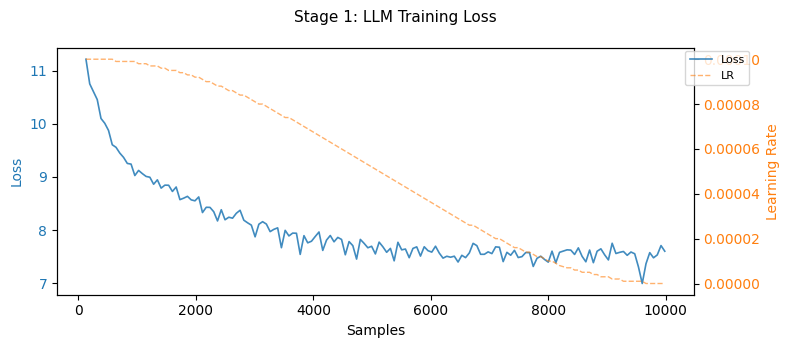

Final loss: 7.6020 | LR: 0.000000 | Samples: 9984


In [4]:
%matplotlib inline
import glob

from tutorials.tutorial_utils import plot_training_loss

llm_exp_dir = sorted(glob.glob("smoke_test_nb/*transformer*"))[-1]
plot_training_loss(llm_exp_dir, "Stage 1: LLM Training Loss")

### Vibe check: Text generation

Load the trained LLM and generate a short text completion. With only 100M parameters and a tiny dataset, the output will not be coherent -- the goal is to confirm the model produces valid tokens and that loading works.

In [5]:
import glob

import torch
from transformers import AutoTokenizer

from vla_foundry.file_utils import load_model_checkpoint
from vla_foundry.models import create_model
from vla_foundry.params.model_params import ModelParams
from vla_foundry.params.train_experiment_params import load_params_from_yaml

# Find the latest LLM experiment directory
llm_exp_dir = sorted(glob.glob("smoke_test_nb/*transformer*"))[0]
print(f"Loading from: {llm_exp_dir}")

# Load model config and create model
model_params = load_params_from_yaml(ModelParams, f"{llm_exp_dir}/config_model.yaml")
model = create_model(model_params)

# Load the latest checkpoint
ckpt_files = sorted(glob.glob(f"{llm_exp_dir}/checkpoints/checkpoint_*.pt"))
print(f"Loading checkpoint: {ckpt_files[-1]}")
load_model_checkpoint(model, ckpt_files[-1])
model.eval()

# Tokenize and generate
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolVLM2-256M-Video-Instruct")
inputs = tokenizer(["The future of robotics is"], return_tensors="pt", padding=True)
with torch.no_grad():
    output = model.generate(inputs["input_ids"], inputs["attention_mask"], max_new_tokens=30)
print("Generated text:")
print(tokenizer.batch_decode(output, skip_special_tokens=True))

Loading from: smoke_test_nb/2026_04_02-12_05_01-model_transformer-lr_0.0001-bsz_64
Loading checkpoint: smoke_test_nb/2026_04_02-12_05_01-model_transformer-lr_0.0001-bsz_64/checkpoints/checkpoint_2.pt
Generated text:
['The future of robotics is a to the\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n']


---
## Stage 2: VLM Training

We add vision capabilities by combining the 100M transformer backbone with a tiny ViT encoder using a minimal sample from [DataComp-12M](https://huggingface.co/datasets/mlfoundations/DataComp-12M). We download one native WebDataset shard, write a local manifest, and run a small training step. The `vlm_100m.yaml` config includes `transformer_100m.yaml` (with `vocab_size: 49280`) and `vit_tiny.yaml`. The `simple_vlm` processor handles tokenization and image preprocessing.

**Note:** LLM→VLM weight transfer requires prefix remapping (not yet automated), so this stage trains from scratch. VLM→VLA transfer in Stage 3 works automatically.

In [6]:
from tutorials.tutorial_utils import download_datacomp_images

datacomp_manifest = download_datacomp_images()

DataComp data already exists at data/datacomp_minimal/manifest.jsonl, skipping download.


In [ ]:
!uv run torchrun --nproc_per_node=1 --nnodes=1 vla_foundry/main.py \
  --model "include vla_foundry/config_presets/models/vlm_100m.yaml" \
  --distributed.fsdp False \
  --data.type image_caption \
  --data.processor simple_vlm \
  --data.dataset_manifest '["data/datacomp_minimal/manifest.jsonl"]' \
  --data.dataset_modality '["image_caption"]' \
  --data.dataset_weighting '[1.0]' \
  --data.seq_len 512 \
  --data.img_num_tokens 256 \
  --data.num_workers 1 \
  --data.allow_multiple_epochs True \
  --total_train_samples 3000 \
  --num_checkpoints 1 \
  --hparams.per_gpu_batch_size 16 \
  --hparams.global_batch_size 32 \
  --hparams.lr 0.001 \
  --hparams.warmup 2 \
  --hparams.torchcompile True \
  --log_every_n_steps 1 \
  --save_path ./smoke_test_nb \
  --wandb False \
  --db_logging False

2026-04-02,19:46:07 | WARNING | Processing metadata not found at data/datacomp_minimal/processing_metadata.json
2026-04-02,19:46:07 | WARNING | No processing metadata found for any data source
2026-04-02,19:46:07 | INFO | Running with a single process. Device cuda:0.
2026-04-02,19:46:08 | INFO | Compiling model with torch.compile()...
Total parameters: 91,670,720
Trainable parameters: 91,670,720
2026-04-02,19:46:09 | INFO | Start checkpoint 0
2026-04-02,19:46:09 | INFO | Dataset 0: adding 45 full epochs in bulk (90 shards, 2880 samples)
2026-04-02,19:46:09 | INFO | Now training on: [data/datacomp_minimal/{shard-0000, shard-0001}.tar (x47)]
2026-04-02,19:46:09 | INFO | Samples: 0 / 3000
2026-04-02,19:46:09 | INFO | Samples in this checkpoint (per dataset): [3008]
Checkpoint 0: 100%|█| 93/93 [00:38<00:00,  2.39step/s, loss=0.2363, lr=0.000000]
Saving checkpoint_1 in ./smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt...
Saving optimizer_1 in ./smoke_

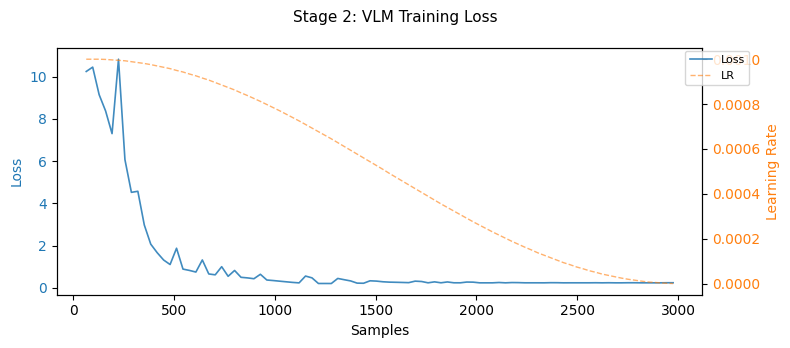

Final loss: 0.2360 | LR: 0.000000 | Samples: 2976


In [8]:
%matplotlib inline
import glob

from tutorials.tutorial_utils import plot_training_loss

vlm_exp_dir = sorted(glob.glob("smoke_test_nb/*vlm*"))[-1]
plot_training_loss(vlm_exp_dir, "Stage 2: VLM Training Loss")

### Vibe check: Image captioning

Load the trained VLM and generate a caption for an image from the training data. With a tiny ViT and 100M backbone trained on minimal data, the caption will not be meaningful -- the goal is to confirm the model loads, processes images, and generates tokens.

Loading from: smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32
Loading checkpoint: smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt


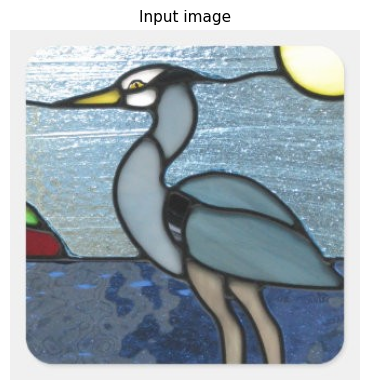

Ground truth: PEI Blue Heron Square Sticker
Generated:     Kangaroo Pocket Drawstring Rogue Squads-Nbh20108PCS


In [9]:
%matplotlib inline
import glob
import io
import tarfile

import matplotlib.pyplot as plt
import torch
from PIL import Image

from vla_foundry.file_utils import load_model_checkpoint
from vla_foundry.models import create_model
from vla_foundry.models.vision_language_backbones.simple_vlm_processor import SimpleVLMProcessor
from vla_foundry.params.model_params import ModelParams
from vla_foundry.params.train_experiment_params import load_params_from_yaml

# Find the latest VLM experiment directory
vlm_exp_dir = sorted(glob.glob("smoke_test_nb/*vlm*"))[-1]
print(f"Loading from: {vlm_exp_dir}")

# Load model config and create model
model_params = load_params_from_yaml(ModelParams, f"{vlm_exp_dir}/config_model.yaml")
model = create_model(model_params)

# Load the latest checkpoint
ckpt_files = sorted(glob.glob(f"{vlm_exp_dir}/checkpoints/checkpoint_*.pt"))
print(f"Loading checkpoint: {ckpt_files[-1]}")
load_model_checkpoint(model, ckpt_files[-1])
model.eval()

# Load a real image from the DataComp training data
img_idx = 2
tar_path = glob.glob("data/datacomp_minimal/shard-*.tar")[0]
with tarfile.open(tar_path) as tar:
    jpgs = [m for m in tar.getmembers() if m.name.endswith(".jpg")]
    test_image = Image.open(io.BytesIO(tar.extractfile(jpgs[img_idx]).read())).convert("RGB")
    gt_caption = tar.extractfile(jpgs[img_idx].name.replace(".jpg", ".txt")).read().decode("utf-8").strip()
# Generate caption
processor = SimpleVLMProcessor()
processor.image_seq_length = 256  # must match data.img_num_tokens
prompt = "<image>"
inputs = processor([test_image], [prompt], return_tensors="pt", max_length=1024)

with torch.no_grad():
    output = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=20,
    )
generated = processor.tokenizer.decode(output[0], skip_special_tokens=True)

# Display image with captions
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(test_image)
ax.axis("off")
ax.set_title("Input image", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Ground truth: {gt_caption}")
print(f"Generated:    {generated}")

---
## Stage 3: VLA Training

The final stage adds action prediction on a tiny local subset of [lerobot/droid_100](https://huggingface.co/datasets/lerobot/droid_100). We download a few metadata files plus the three DROID camera videos, build a compatibility copy for the repo's LeRobot preprocessor, convert that into local tar shards, and train a short VLA run. The VLM checkpoint from Stage 2 is loaded via `vision_language_backbone.resume_from_checkpoint`.

In [10]:
from tutorials.tutorial_utils import download_droid_robotics

droid_compat_root = download_droid_robotics()

Using existing DROID compat data at data/droid_100_minimal/lerobot_compat.


In [11]:
import glob
import subprocess
from pathlib import Path

DROID_CAMERAS = [
    "observation.images.exterior_image_1_left",
    "observation.images.exterior_image_2_left",
    "observation.images.wrist_image_left",
]
COMPAT_ROOT = Path("data/droid_100_minimal/lerobot_compat").resolve()
PREPROC_ROOT = Path("data/droid_100_minimal/preprocessed").resolve()
PREPROC_MANIFEST = PREPROC_ROOT / "shards/manifest.jsonl"
PREPROC_STATS = PREPROC_ROOT / "shards/stats.json"

vlm_exp_dir = sorted(glob.glob("smoke_test_nb/*vlm*"))[-1]
vlm_ckpt = sorted(glob.glob(f"{vlm_exp_dir}/checkpoints/checkpoint_*.pt"))[-1]

if PREPROC_MANIFEST.exists() and PREPROC_STATS.exists():
    print(f"Using existing preprocessed data at {PREPROC_MANIFEST}.")
else:
    preprocess_cmd = [
        "uv",
        "run",
        "--group",
        "preprocessing",
        "python",
        "vla_foundry/data/preprocessing/preprocess_robotics_to_tar.py",
        "--type",
        "lerobot",
        "--source_episodes",
        f"['{COMPAT_ROOT}']",
        "--output_dir",
        str(PREPROC_ROOT),
        "--camera_names",
        str(DROID_CAMERAS),
        "--observation_keys",
        "['observation.state']",
        "--action_keys",
        "['action']",
        "--samples_per_shard",
        "32",
        "--config_path",
        "tutorials/tutorial_utils/robotics_preprocessing_params_tutorial.yaml",
        "--max_episodes_to_process",
        "2",
        "--db_logging",
        "False",
    ]
    print("Running preprocessing:")
    print(" ".join(preprocess_cmd))
    subprocess.run(preprocess_cmd, check=True)

print(f"VLM checkpoint for backbone: {vlm_ckpt}")
print(f"DROID manifest: {PREPROC_MANIFEST}")
print(f"DROID stats:    {PREPROC_STATS}")

Using existing preprocessed data at /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/manifest.jsonl.
VLM checkpoint for backbone: smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt
DROID manifest: /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/manifest.jsonl
DROID stats:    /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/stats.json


In [13]:
import glob
import subprocess
from pathlib import Path

vlm_exp_dir = sorted(glob.glob("smoke_test_nb/*vlm*"))[-1]
vlm_ckpt = sorted(glob.glob(f"{vlm_exp_dir}/checkpoints/checkpoint_*.pt"))[-1]
droid_manifest = str(Path("data/droid_100_minimal/preprocessed/shards/manifest.jsonl").resolve())
droid_stats = str(Path("data/droid_100_minimal/preprocessed/shards/stats.json").resolve())

# Camera names use the short form (without "observation.images." prefix)
# because the training pipeline strips prefixes via key.split(".")[-2]
cameras = '["exterior_image_1_left","exterior_image_2_left","wrist_image_left"]'

cmd = [
    "uv",
    "run",
    "torchrun",
    "--nproc_per_node=1",
    "--nnodes=1",
    "vla_foundry/main.py",
    "--config_path",
    "vla_foundry/config_presets/training_jobs/vla_diffusion_tiny_test.yaml",
    "--model",
    "include vla_foundry/config_presets/models/vla_diffusion_100m.yaml",
    "--model.vision_language_backbone.resume_from_checkpoint",
    vlm_ckpt,
    "--data.dataset_manifest",
    f'["{droid_manifest}"]',
    "--data.dataset_statistics",
    f'["{droid_stats}"]',
    "--data.camera_names",
    cameras,
    "--data.action_fields",
    '["action"]',
    "--data.lowdim_past_timesteps",
    "2",
    "--data.proprioception_fields",
    '["observation.state"]',
    "--data.language_instruction_types",
    '["original"]',
    "--data.pose_groups",
    "[]",
    "--data.intrinsics_fields",
    "[]",
    "--data.extrinsics_fields",
    "[]",
    "--data.processor",
    "simple_vlm",
    "--data.allow_multiple_epochs",
    "True",
    "--data.num_workers",
    "0",
    "--distributed.fsdp",
    "False",
    "--total_train_samples",
    "128",
    "--num_checkpoints",
    "1",
    "--max_checkpoint_limit",
    "2",
    "--hparams.per_gpu_batch_size",
    "1",
    "--hparams.global_batch_size",
    "1",
    "--hparams.warmup",
    "2",
    "--save_path",
    "./smoke_test_nb",
    "--wandb",
    "False",
    "--db_logging",
    "False",
]
print("Running VLA training...\n")
subprocess.run(cmd, check=True)

Running VLA training...



INFO:root:Loaded processing metadata from /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/processing_metadata.json
2026-04-02,23:08:58 | INFO | Loaded processing metadata from /media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/processing_metadata.json
INFO:root:Running with a single process. Device cuda:0.
2026-04-02,23:08:58 | INFO | Running with a single process. Device cuda:0.
INFO:root:=> resuming checkpoint 'smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt' (checkpoint 1)
2026-04-02,23:08:59 | INFO | => resuming checkpoint 'smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt' (checkpoint 1)


Total parameters: 104,489,607
Trainable parameters: 104,489,607


INFO:root:Start checkpoint 0
2026-04-02,23:09:00 | INFO | Start checkpoint 0
INFO:root:Now training on: [/media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/{shard_000000, shard_000007, shard_000009, shard_000010, shard_000012}.tar]
2026-04-02,23:09:00 | INFO | Now training on: [/media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/{shard_000000, shard_000007, shard_000009, shard_000010, shard_000012}.tar]
INFO:root:Samples: 0 / 128
2026-04-02,23:09:00 | INFO | Samples: 0 / 128
INFO:root:Samples in this checkpoint (per dataset): [134]
2026-04-02,23:09:00 | INFO | Samples in this checkpoint (per dataset): [134]
INFO:root:RoboticsNormalizer initialized: method=percentile_1_99, scope=per_timestep
2026-04-02,23:09:01 | INFO | RoboticsNormalizer initialized: method=percentile_1_99, scope=per_timestep
202

Saving checkpoint_1 in ./smoke_test_nb/2026_04_02-23_08_58-model_diffusion_policy-lr_0.0005-bsz_1/checkpoints/checkpoint_1.pt...
Saving optimizer_1 in ./smoke_test_nb/2026_04_02-23_08_58-model_diffusion_policy-lr_0.0005-bsz_1/checkpoints/optimizer_1.pt...


INFO:root:Model has seen the desired number of samples. Ending training.
2026-04-02,23:09:12 | INFO | Model has seen the desired number of samples. Ending training.


CompletedProcess(args=['uv', 'run', 'torchrun', '--nproc_per_node=1', '--nnodes=1', 'vla_foundry/main.py', '--config_path', 'vla_foundry/config_presets/training_jobs/vla_diffusion_tiny_test.yaml', '--model', 'include vla_foundry/config_presets/models/vla_diffusion_100m.yaml', '--model.vision_language_backbone.resume_from_checkpoint', 'smoke_test_nb/2026_04_02-19_46_07-model_vlm-lr_0.001-bsz_32/checkpoints/checkpoint_1.pt', '--data.dataset_manifest', '["/media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/manifest.jsonl"]', '--data.dataset_statistics', '["/media/jeanmercat/471dbe07-0fd5-429a-b5d9-63c4eb5824b4/Code/lbm2_bis/worktrees/jean/tutorial_llm_vlm_vla/data/droid_100_minimal/preprocessed/shards/stats.json"]', '--data.camera_names', '["exterior_image_1_left","exterior_image_2_left","wrist_image_left"]', '--data.action_fields', '["action"]', '--data.lowdim_past_timesteps', '2', '--data.pro

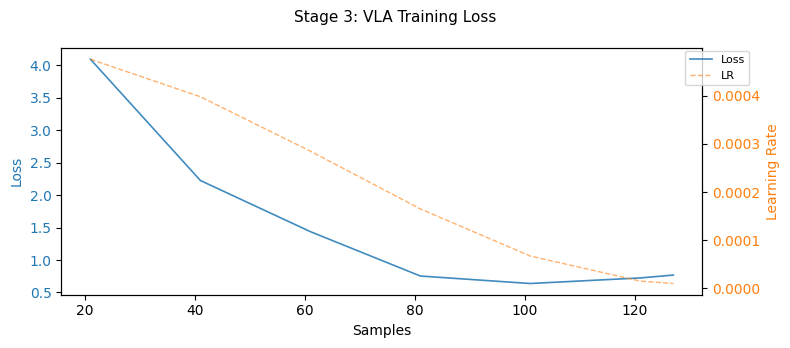

Final loss: 0.7680 | LR: 0.000010 | Samples: 127


In [14]:
%matplotlib inline
import glob

from tutorials.tutorial_utils import plot_training_loss

vla_exp_dir = sorted(glob.glob("smoke_test_nb/*diffusion*"))[-1]
plot_training_loss(vla_exp_dir, "Stage 3: VLA Training Loss")

### Vibe check: VLA action prediction

Load the trained VLA, feed it a real robotics sample from the training data, run `generate_actions()` to produce predicted action trajectories, and compare them against the ground truth. We also display camera images from the sample to show what the model sees.

Loaded VLA from smoke_test_nb/2026_04_02-23_08_58-model_diffusion_policy-lr_0.0005-bsz_1


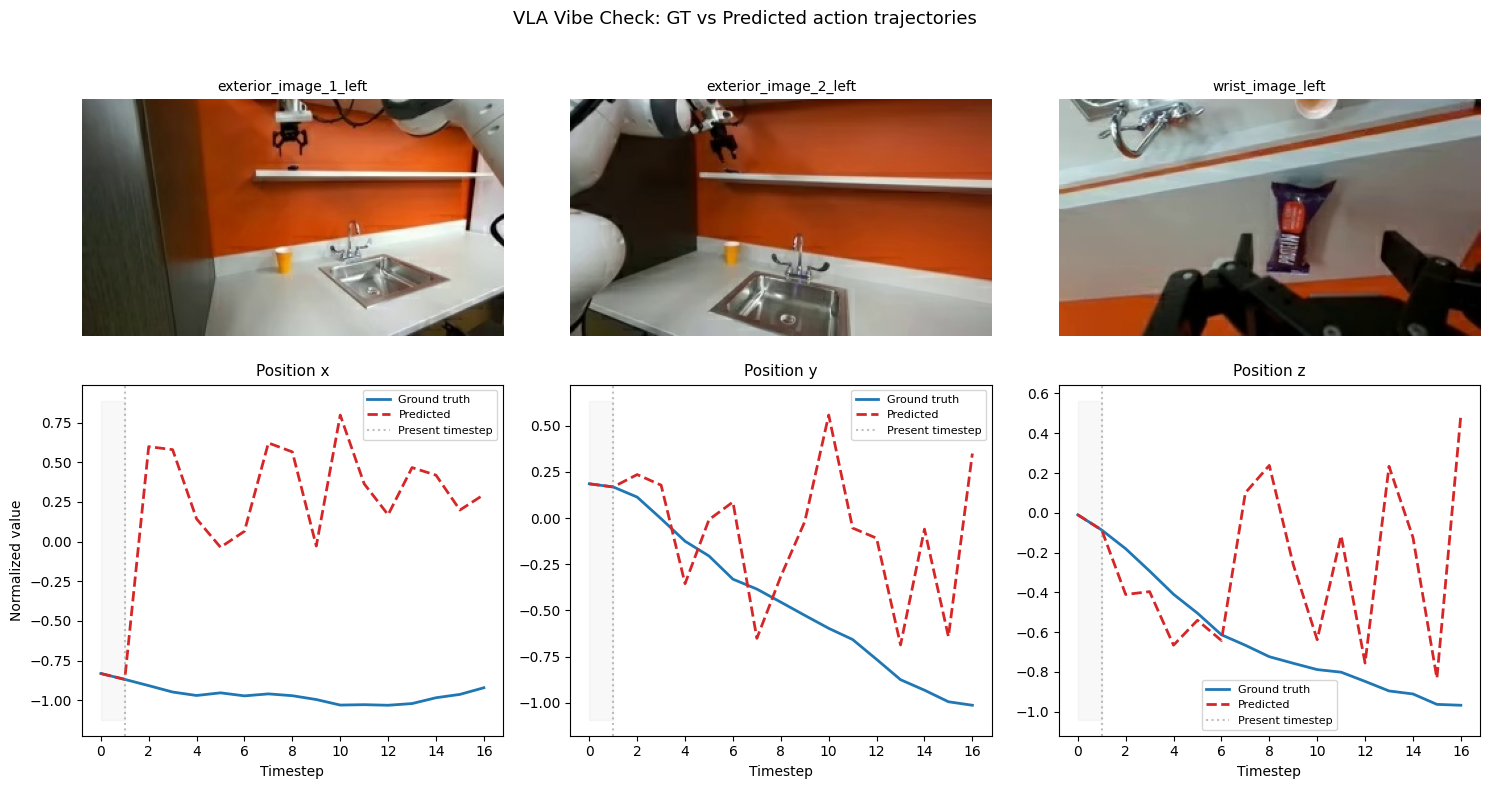

Actions: 7 dims, 17 timesteps (2 past (past actions + past observations) + 1 present (current observation, no action) + 14 future (no observations, no actions))


In [15]:
%matplotlib inline
import glob
import io
import json
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from vla_foundry.data.pipelines.robotics import extract_robotics_fields
from vla_foundry.data.processor.robotics_processor import RoboticsProcessor
from vla_foundry.file_utils import load_model_checkpoint
from vla_foundry.models import create_model
from vla_foundry.params.model_params import ModelParams
from vla_foundry.params.train_experiment_params import load_params_from_yaml

# ---------- 1. Load VLA model ----------
vla_exp_dir = sorted(glob.glob("smoke_test_nb/*diffusion*"))[-1]
model_params = load_params_from_yaml(ModelParams, f"{vla_exp_dir}/config_model.yaml")
model = create_model(model_params)
ckpt = sorted(glob.glob(f"{vla_exp_dir}/checkpoints/checkpoint_*.pt"))[-1]
load_model_checkpoint(model, ckpt)
model.eval().cuda()
print(f"Loaded VLA from {vla_exp_dir}")

# ---------- 2. Load processor (with normalizer) ----------
processor = RoboticsProcessor.from_pretrained(vla_exp_dir)
data_params = processor.data_params

# ---------- 3. Read one sample from a preprocessed tar ----------
tar_path = glob.glob("data/droid_100_minimal/preprocessed/shards/shard_*.tar")[0]
raw_sample = {}
with tarfile.open(tar_path, "r") as tar:
    members = tar.getmembers()
    first_id = members[0].name.split(".")[0]
    for m in members:
        if not m.name.startswith(first_id):
            break
        suffix = m.name[len(first_id) + 1 :]
        f = tar.extractfile(m)
        if suffix.endswith(".jpg"):
            raw_sample[suffix] = torch.from_numpy(np.array(Image.open(io.BytesIO(f.read())).convert("RGB"))).permute(
                2, 0, 1
            )
        elif suffix.endswith(".npz"):
            raw_sample[suffix] = dict(np.load(io.BytesIO(f.read())))
        elif suffix.endswith(".json"):
            raw_sample[suffix] = json.load(f)

# ---------- 4. Build a batch ----------
fields = extract_robotics_fields(
    raw_sample,
    language_instruction_types=list(data_params.language_instruction_types),
    action_fields=list(data_params.action_fields),
    proprioception_fields=list(data_params.proprioception_fields),
    lowdim_past_timesteps=data_params.lowdim_past_timesteps,
    lowdim_future_timesteps=data_params.lowdim_future_timesteps,
)
batch_of_one = {k: [v] for k, v in fields.items()}
batch = processor.process_inputs(batch_of_one, image_names=list(data_params.image_names))
batch = processor.add_action_and_proprioception_fields(
    batch,
    action_fields=list(data_params.action_fields),
    proprioception_fields=list(data_params.proprioception_fields),
)

# ---------- 5. Run generate_actions ----------
actions = batch["actions"].cuda()
past_mask = torch.as_tensor(np.stack(fields["past_mask"][None]), dtype=torch.bool).cuda()

with torch.no_grad():
    predicted = model.generate_actions(
        input_ids=batch["input_ids"].cuda(),
        pixel_values=batch["pixel_values"].cuda(),
        actions=actions,
        attention_mask=batch["attention_mask"].cuda().bool(),
        attention_mask_images=batch["attention_mask_images"].cuda().bool(),
        past_mask=past_mask,
        proprioception=batch["proprioception"].cuda() if "proprioception" in batch else None,
        num_inference_steps=10,
    )

gt = actions.cpu().numpy()[0]
pred = predicted.cpu().numpy()[0]
past = past_mask.cpu().numpy()[0]
T, D = gt.shape
t = np.arange(T)
future_start = int(past.sum())

# ---------- 6. Plot: cameras (top) + x/y/z position (bottom, 3 plots) ----------
cam_keys = sorted([k for k in raw_sample if k.endswith("_t0.jpg")])[:3]
axis_names = ["x", "y", "z"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: camera images
for i in range(3):
    if i < len(cam_keys):
        img = raw_sample[cam_keys[i]]
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        cam_name = cam_keys[i].replace("observation.images.", "").replace("_t0.jpg", "")
        axes[0, i].set_title(cam_name, fontsize=10)
    axes[0, i].axis("off")

# Bottom row: one plot per xyz dimension
for i in range(3):
    ax = axes[1, i]
    if i < D:
        ax.plot(t, gt[:, i], "-", color="tab:blue", linewidth=2, label="Ground truth")
        ax.plot(t, pred[:, i], "--", color="tab:red", linewidth=2, label="Predicted")
        ax.axvline(future_start - 1, color="gray", ls=":", alpha=0.5, label="Present timestep")
        ax.fill_betweenx(
            ax.get_ylim() if ax.get_ylim()[0] != ax.get_ylim()[1] else [-1, 1],
            0,
            future_start - 1,
            alpha=0.05,
            color="gray",
        )
        ax.set_title(f"Position {axis_names[i]}", fontsize=11)
        ax.set_xlabel("Timestep")
        if i == 0:
            ax.set_ylabel("Normalized value")
        ax.legend(fontsize=8)
    else:
        ax.axis("off")

plt.suptitle("VLA Vibe Check: GT vs Predicted action trajectories", fontsize=13)
plt.tight_layout()
plt.show()
print(
    f"Actions: {D} dims, {T} timesteps ({future_start} past (past actions + past observations) "
    "+ 1 present (current observation, no action) "
    f"+ {T - future_start - 1} future (no observations, no actions))"
)

---
## Evaluation References

For rigorous benchmarking beyond these quick vibe checks:

- **LLM evaluation:** [lm-evaluation-harness](https://github.com/TRI-ML/lm-evaluation-harness-vlafoundry) -- integrates with VLA Foundry checkpoints for standard LLM benchmarks
- **VLM evaluation:** [VLMEvalKit](https://github.com/TRI-ML/VLMEvalKit) -- supports VLA Foundry model loading for vision-language benchmarks
- **VLA evaluation:** See `examples/deployment/lbm_eval/README.md` for simulation evaluation with lbm_eval, or use `vla_foundry/eval/run_eval.py` for other environments (robocasa, libero, calvin, robosuite)